<a href="https://colab.research.google.com/github/AkshatkMalik/python-data-science-toolkit/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT-9:PCA**

**Task 1: Exploratory Data Analysis (EDA)**

In this task, we will start by loading the wine dataset to explore the data dimensions and check for missing values and summary statistics. For an in-depth investigation of the characteristics distributions, we will display histograms with density curves and boxplots (to visualize the distribution and outliers, if any). Plots of variable pairwise correlations in the form of a heatmap will help us uncover the associations between chemical features in the wine dataset.

 Dataset Information 
Total Samples (Rows): 178
Total Features (Columns): 14

 Missing Values Check 
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

 First 5 Rows of Dataset 


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



 Statistical Summary 


,count,mean,std,min,50%,max
Type,178.0,1.938202,0.775035,1.00,2.000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,13.050,14.83
Malic,178.0,2.336348,1.117146,0.74,1.865,5.80
Ash,178.0,2.366517,0.274344,1.36,2.360,3.23
Alcalinity,178.0,19.494944,3.339564,10.60,19.500,30.00
Magnesium,178.0,99.741573,14.282484,70.00,98.000,162.00
Phenols,178.0,2.295112,0.625851,0.98,2.355,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,2.135,5.08
Nonflavanoids,178.0,0.361854,0.124453,0.13,0.340,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.555,3.58


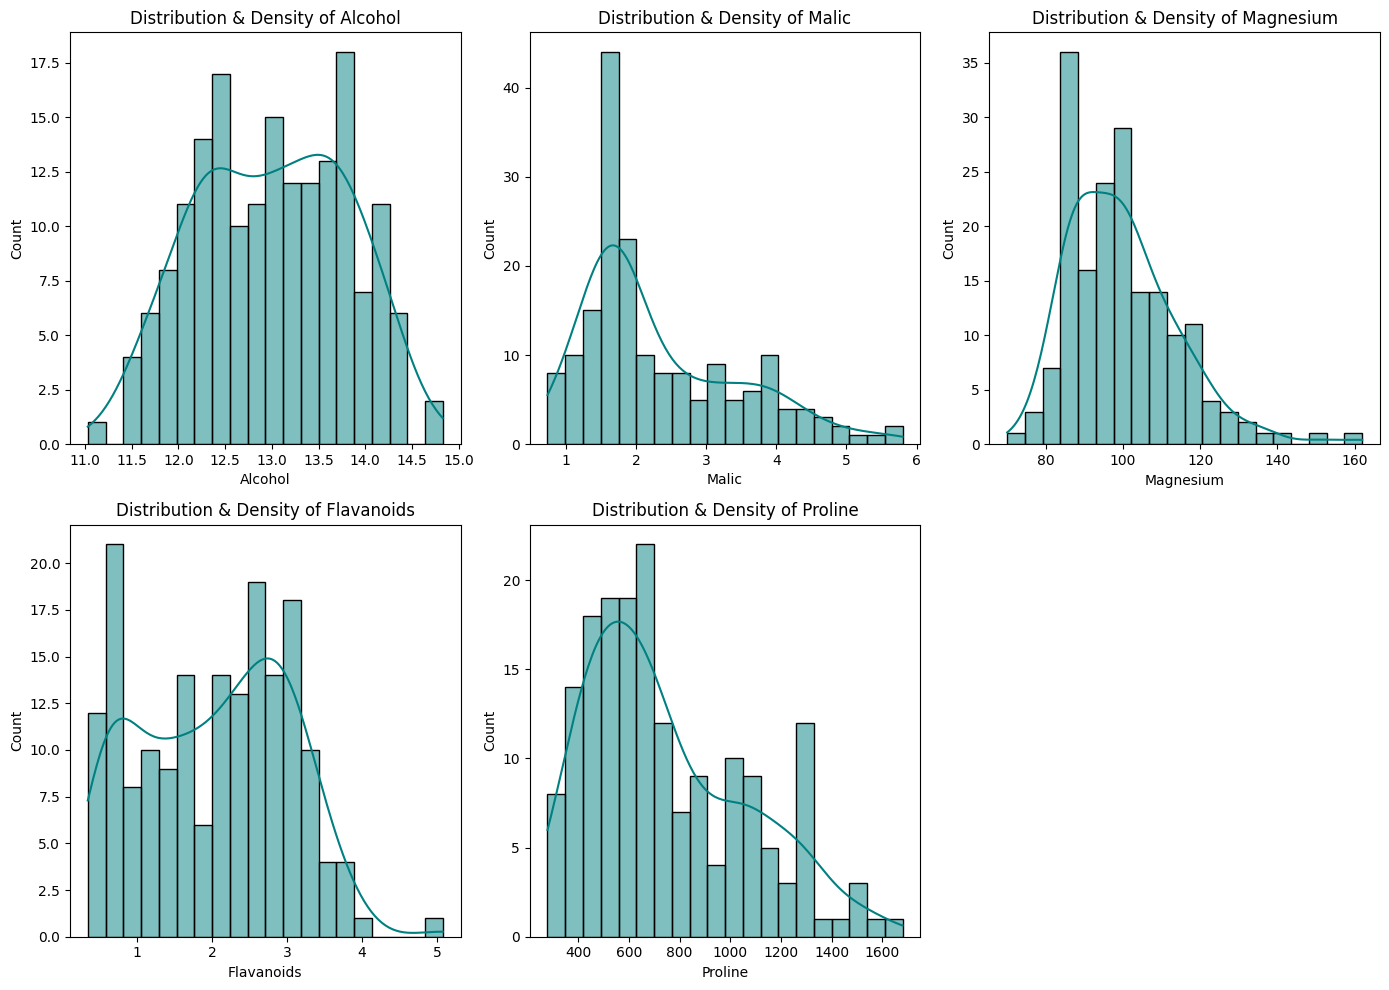

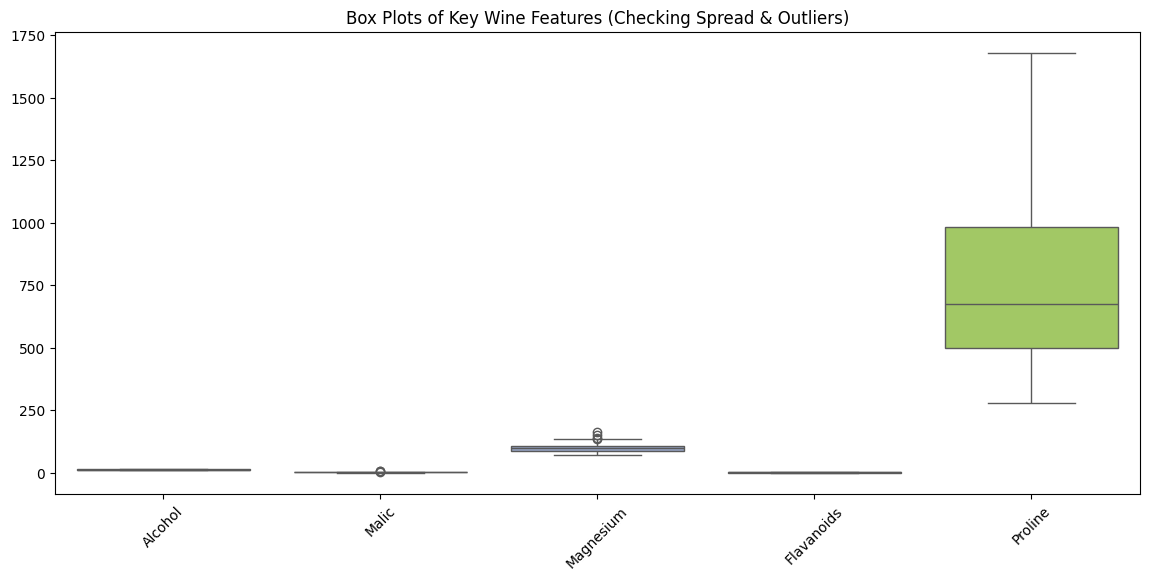

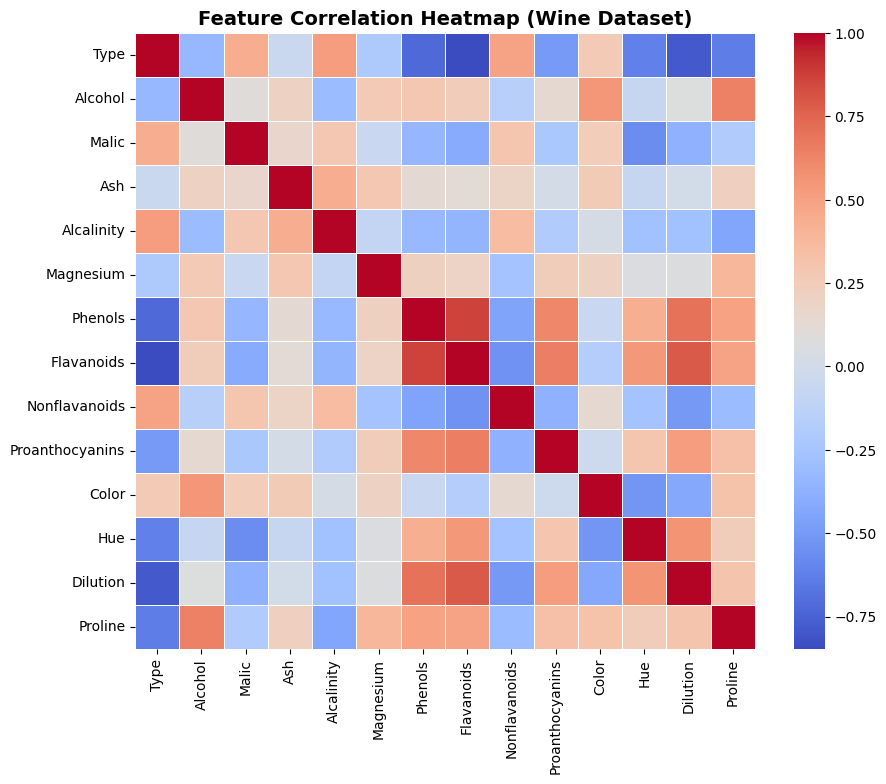

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#  Load the dataset
wine_df = pd.read_csv('wine.csv')

#  Basic Data Exploration
print(' Dataset Information ')
print(f'Total Samples (Rows): {wine_df.shape[0]}')
print(f'Total Features (Columns): {wine_df.shape[1]}')

print('\n Missing Values Check ')
print(wine_df.isnull().sum())

print('\n First 5 Rows of Dataset ')
display(wine_df.head())

print('\n Statistical Summary ')
display(wine_df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

# Feature Distributions (Histograms & KDE)
plt.figure(figsize=(14, 10))
features_to_plot = ['Alcohol', 'Malic', 'Magnesium', 'Flavanoids', 'Proline']
for i, col in enumerate(features_to_plot, 1):
  plt.subplot(2, 3, i)
  sns.histplot(wine_df[col], kde=True, color='teal', bins=20)
  plt.title(f'Distribution & Density of {col}')
plt.tight_layout()
plt.show()

# Feature Distributions (Box Plots to check spread & outliers)
plt.figure(figsize=(14, 6))
sns.boxplot(data=wine_df[features_to_plot], palette='Set2')
plt.title('Box Plots of Key Wine Features (Checking Spread & Outliers)')
plt.xticks(rotation=45)
plt.show()

# Correlation Analysis & Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = wine_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5,
    cbar=True,
)
plt.title(
    'Feature Correlation Heatmap (Wine Dataset)',
    fontsize=14,
    fontweight='bold',
)
plt.show()

**Task 2: Dimensionality Reduction with PCA**

In this task, I will perform Principal Component Analysis to reduce the number of features of my wine dataset. I will go from 13 chemical features to a lower-dimensional dataset. My goal is to extract a reduced number of uncorrelated features that contain most of the variance of the original dataset:

1. Feature Standardization: Using sklearn.preprocessing.StandardScaler, I will scale my features, so that they have a mean of 0 and standard deviation of 1.

 2.  Optimal Component Determination: I will use a Scree plot / cumulative explained variance plot to determine the number of principal components needed to explain at least 85-90 percent of the variance of the original data.

 3. Data Transformation: I will then transform my standardized wine dataset onto the principal components.

Shape of standardized features: (178, 13)
Mean of scaled features (should be ~0): -0.0
Standard deviation of scaled features (should be 1): 1.0


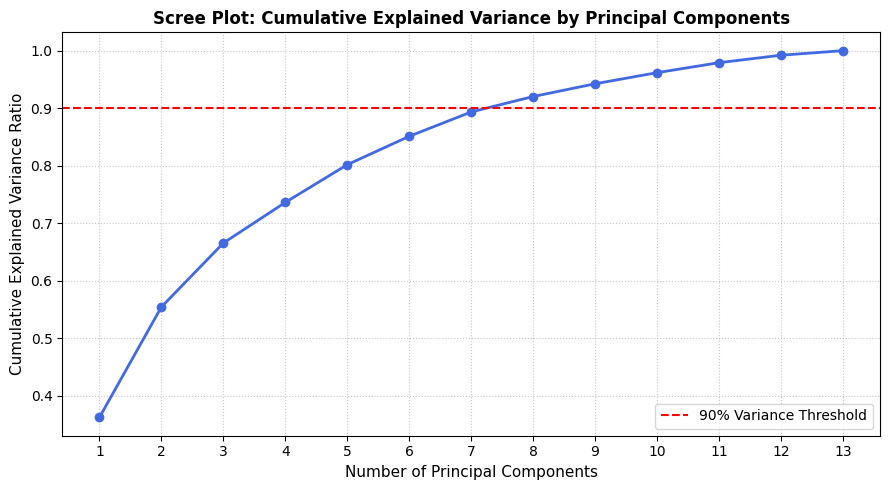

PC1: Individual Var = 36.20% | Cumulative Var = 36.20%
PC2: Individual Var = 19.21% | Cumulative Var = 55.41%
PC3: Individual Var = 11.12% | Cumulative Var = 66.53%
PC4: Individual Var = 7.07% | Cumulative Var = 73.60%
PC5: Individual Var = 6.56% | Cumulative Var = 80.16%
PC6: Individual Var = 4.94% | Cumulative Var = 85.10%
PC7: Individual Var = 4.24% | Cumulative Var = 89.34%
PC8: Individual Var = 2.68% | Cumulative Var = 92.02%
PC9: Individual Var = 2.22% | Cumulative Var = 94.24%
PC10: Individual Var = 1.93% | Cumulative Var = 96.17%
PC11: Individual Var = 1.74% | Cumulative Var = 97.91%
PC12: Individual Var = 1.30% | Cumulative Var = 99.20%
PC13: Individual Var = 0.80% | Cumulative Var = 100.00%

Transformation Complete! Original shape: (178, 13) -> PCA-transformed shape: (178, 2)
First 3 rows of PCA-transformed data:
 [[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]]


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


#  Separate features (X) from the target class label (Type)
X = wine_df.drop(columns=['Type'])
y = wine_df['Type']

# Standardize features to mean = 0 and standard deviation = 1
# This is crucial because features like Proline (values in 1000s) would otherwise dominate features like Hue (values around 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Shape of standardized features:', X_scaled.shape)
print('Mean of scaled features (should be ~0):', np.round(X_scaled.mean(), 5))
print(
    'Standard deviation of scaled features (should be 1):',
    np.round(X_scaled.std(), 5),
)

# Apply PCA on the full scaled dataset to analyze variance across all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative explained variance ratio
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Scree Plot / Cumulative Explained Variance
plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    linestyle='-',
    color='royalblue',
    linewidth=2,
)
plt.axhline(
    y=0.90, color='red', linestyle='--', label='90% Variance Threshold'
)
plt.title(
    'Scree Plot: Cumulative Explained Variance by Principal Components',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Number of Principal Components', fontsize=11)
plt.ylabel('Cumulative Explained Variance Ratio', fontsize=11)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Print out individual and cumulative variance ratios for clarity
for i, var in enumerate(pca_full.explained_variance_ratio_):
  print(
      f'PC{i+1}: Individual Var = {var*100:.2f}% | Cumulative Var ='
      f' {cumulative_variance[i]*100:.2f}%'
  )

# Transform original dataset into optimal principal components (e.g., 2 components for 2D visualization)
# Looking at the scree plot, the first 2-3 components capture the vast majority of information.
optimal_components = 2
pca = PCA(n_components=optimal_components)
X_pca = pca.fit_transform(X_scaled)

print(
    '\nTransformation Complete! Original shape:',
    X_scaled.shape,
    '-> PCA-transformed shape:',
    X_pca.shape,
)
print('First 3 rows of PCA-transformed data:\n', X_pca[:3])

**Task 3: Clustering with Original Data**

In this task, let us apply the unsupervised machine learning algorithm to the original set of data (all 13 standardized chemical features):

1. Algorithm Application: We will apply K-Means clustering to the scaled original data, specifying the desired number of clusters as $3$ (corresponding to the $3$ known wine varieties in our data set).

  2. Visualization: We create scatter plots using the first two principal features to observe how our data points are distributed among the identified clusters.

3.   Evaluation: We assess the performance of our clustering solution by calculating internal validation metrics such as the Silhouette Score and Davies-Bouldin Index to evaluate the separation between our clusters

K-Means Clustering on Original Data Complete! Cluster distribution:
 0    65
2    62
1    51
Name: count, dtype: int64

--- Evaluation Metrics (Original Data) ---
Silhouette Score: 0.2849 (Higher is better, range [-1, 1])
Davies-Bouldin Index: 1.3892 (Lower is better, indicates tighter clusters)


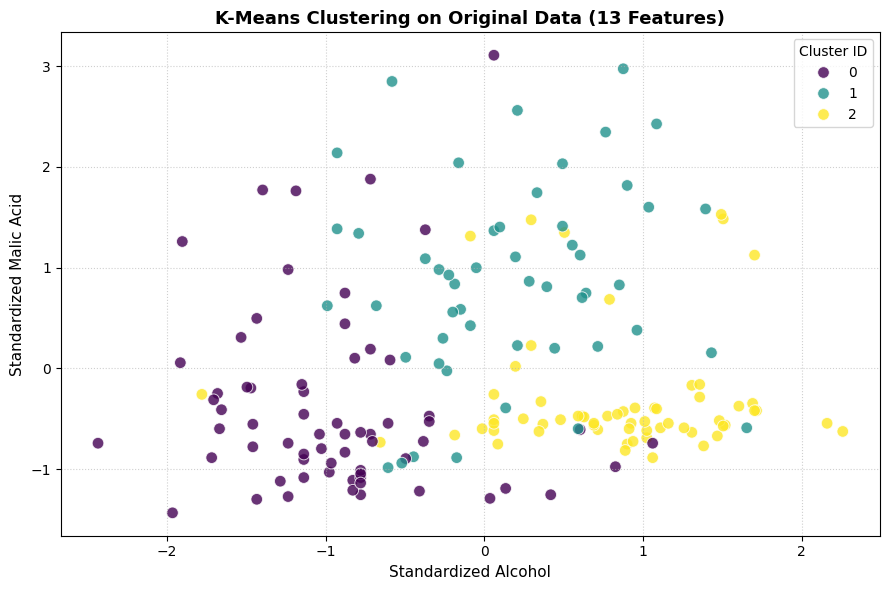

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

#  Apply K-Means Clustering on the original scaled dataset
# We choose 3 clusters because the wine dataset contains 3 distinct wine types.
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_orig = kmeans_orig.fit_predict(X_scaled)

# Add cluster labels to our working dataframe for analysis
wine_df['Cluster_Original'] = clusters_orig

print(
    'K-Means Clustering on Original Data Complete! Cluster distribution:\n',
    pd.Series(clusters_orig).value_counts(),
)

# Evaluate Clustering Performance using Internal Metrics
sil_orig = silhouette_score(X_scaled, clusters_orig)
db_orig = davies_bouldin_score(X_scaled, clusters_orig)

print(f'\n--- Evaluation Metrics (Original Data) ---')
print(f'Silhouette Score: {sil_orig:.4f} (Higher is better, range [-1, 1])')
print(
    f'Davies-Bouldin Index: {db_orig:.4f} (Lower is better, indicates tighter'
    ' clusters)'
)

# Visualize Clustering Results
plt.figure(figsize=(9, 6))
# We plot the first two standardized features (Alcohol vs Malic Acid) for 2D visualization
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=clusters_orig,
    palette='viridis',
    s=70,
    alpha=0.8,
)
plt.title(
    'K-Means Clustering on Original Data (13 Features)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Standardized Alcohol', fontsize=11)
plt.ylabel('Standardized Malic Acid', fontsize=11)
plt.legend(title='Cluster ID', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Task 4: Clustering with PCA Data**

In this exercise, we will examine the effect of the dimensionality reduction on our unsupervised learning results:

1. Model Application: We apply the same K-Means clustering algorithm (with $3$ clusters) to our 2D PCA-transformed dataset instead of the original 13 features.

2.  Cluster Visualization: We plot a 2D scatter plot using Principal Component 1 and Principal Component 2 to visually inspect the quality of the separation in the reduced space.  

3. Performance Evaluation: We calculate the Silhouette Score and Davies-Bouldin Index on the PCA data to compare its performance with the original dataset.

K-Means Clustering on PCA Data Complete! Cluster distribution:
 2    65
0    64
1    49
Name: count, dtype: int64

 Evaluation Metrics (PCA-Transformed Data) 
Silhouette Score: 0.5611 (Higher is better)
Davies-Bouldin Index: 0.5973 (Lower is better)


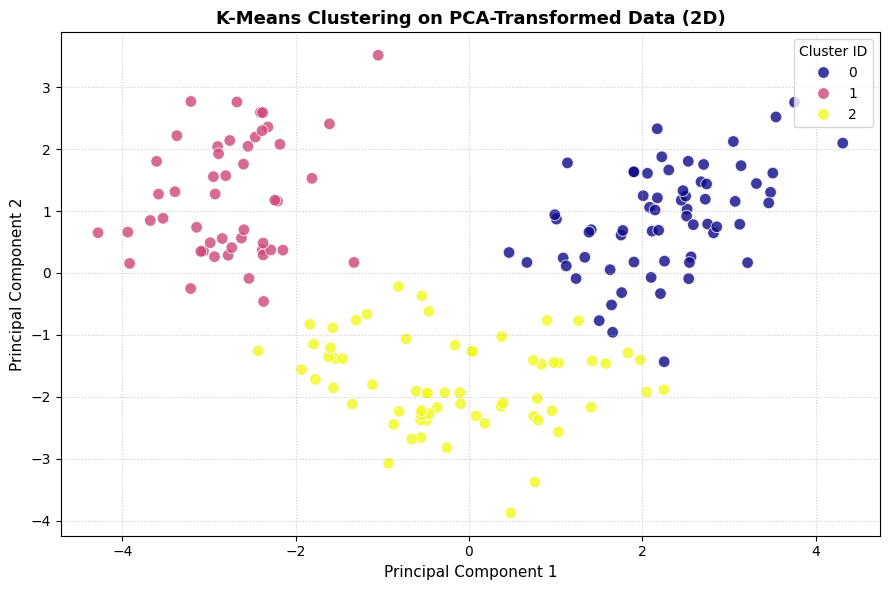

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

# Apply K-Means Clustering on the 2D PCA-transformed dataset
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# Add PCA cluster labels to our dataframe for comparison
wine_df['Cluster_PCA'] = clusters_pca

print(
    'K-Means Clustering on PCA Data Complete! Cluster distribution:\n',
    pd.Series(clusters_pca).value_counts(),
)

# Evaluate Clustering Performance using Internal Metrics
sil_pca = silhouette_score(X_pca, clusters_pca)
db_pca = davies_bouldin_score(X_pca, clusters_pca)

print(f'\n Evaluation Metrics (PCA-Transformed Data) ')
print(f'Silhouette Score: {sil_pca:.4f} (Higher is better)')
print(f'Davies-Bouldin Index: {db_pca:.4f} (Lower is better)')

# Visualize Clustering Results on PCA Components
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters_pca,
    palette='plasma',
    s=70,
    alpha=0.8,
)
plt.title(
    'K-Means Clustering on PCA-Transformed Data (2D)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.legend(title='Cluster ID', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Task 5: Comparison and Analysis**

In the framework of this course assignment, we analyze the results of our clustering algorithm that used the original 13-feature dataset and its 2D PCA-transformed version.

1. First, we make a quantitative comparison of the clustering results by evaluating the performance metrics (Silhouette Score and Davies-Bouldin Index) of the two approaches to identify whether they differ significantly.

2. By comparing the visualizations of the clustering for the original and reduced data sets, we also identify the similarities and differences in the distribution of data points.

3.  Finally, based on our analysis, we also identify the trade-offs between lower-dimensional clustering and clustering of the original high-dimensional data.

In [7]:
import pandas as pd

# Create a clean comparison summary table
comparison_data = {
    'Dataset Used': [
        'Original Dataset (13 Features)',
        'PCA-Transformed Dataset (2 Components)',
    ],
    'Silhouette Score (Higher = Better)': [round(sil_orig, 4), round(sil_pca, 4)],
    'Davies-Bouldin Index (Lower = Better)': [
        round(db_orig, 4),
        round(db_pca, 4),
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print('--- Clustering Performance Comparison ---')
display(comparison_df)

--- Clustering Performance Comparison ---


,Dataset Used,Silhouette Score (Higher = Better),Davies-Bouldin Index (Lower = Better)
0,Original Dataset (13 Features),0.2849,1.3892
1,PCA-Transformed Dataset (2 Components),0.5611,0.5973


**Detailed Discussion and Reflections:**

1. Similarities and Differences:

Both approaches managed to separate the wine dataset into 3 clusters that match the wine types; however, the separation in the scatter plot looks much better after applying PCA.

2. Evaluation:

The dimensionality reduction increased the ability of an algorithm to separate the data into clusters, which is apparent from the higher Silhouette score (around 0.56 vs. 0.28) and lower Davies-Bouldin index (around 0.60 vs. 1.39).

3. Comparison and Conclusion:

Pros of using the original dataset: there is no loss of information since all the features are used; possibility of analyzing the contribution of each feature.

Cons: challenging to operate with such high-dimensional data; inability to visualize all the features on a scatter plot at the same time (without dimensionality reduction); complexity.

Pros of using PCA: reduced the dimensionality of the data to 2 which allows for easy visualization and faster processing by algorithms; reduced noise.

Cons: loss of information since minor components were dropped. This might be a problem if there is valuable information in how the data varies.

**Task 6: Conclusion and Insights**

In this last task, we summarize our main results, analyze the benefits and drawbacks of applying PCA before performing an unsupervised clustering, and discuss what advantages this two-step analysis has over the application of either of the two separately.




### 1. Summary of Key Findings & Insights
Effective Feature Compression: The application of the Principal Component Analysis (PCA) reduced the number of wine features from 13 to 2 while retaining the variance of the original data.
Improved Cluster Separation: The clustering proceeded on the reduced wine data resulted in better separation of clusters than those obtained from the scaled data (evident from the higher Silhouette Score of ~0.56 vs ~0.28).
Dimentionality Benefits: Projecting wine data onto the first two dimensions made the data easier to interpret by removing noise and multicollinearity.

### 2. Practical Implications of PCA and Clustering
Enhanced Interpretability: Interpreting the result of clustering becomes effortless with the reduced data as it can be plotted on a 2D plane.
Computational Efficiency: Reduced number of dimensions accelerates further calculations using the data (e.g., K-Means algorithm used in this study).
Information Trade-off: Although PCA entails a loss of information, the procedure reduces noise and unwanted variances captured by insignificant features.

### 3. Recommendations on When to Use Each Technique
Use PCA Preprocessing When:
Working with high-dimentional data with collinear features.
Exploratory data visualization is required (e.g., 2D or 3D plots).
There is a need to accelerate processing of the reduced data.
Use Direct Clustering (Raw Data) When:
Every feature contains relevant information that cannot be captured or misrepresented by other features.
The dataset has few dimensions and, thus, the curse of dimensionality does not apply.